# 📉 Прогноз error_rate — Ridge + Walk-forward (Схема 2)

Методика повторяет `cpu_walkforward.ipynb` (Яндекс ML Handbook §10.3): набор лагов / скользящих окон / EWM / гармоник, та же схема walk-forward. CatBoost больше не используется — целевая модель **Ridge** с теми же признаками, что и для CPU.

Итоговый артефакт — единый `joblib`-bundle (`model`, `scaler`, `feature_cols`, `meta`) совместимый с `RidgePredictor` в `app/predictor.py`.

## 1. Настройка окружения

In [1]:
import warnings; warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# ── Единый тёмный стиль ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22', 'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9', 'axes.titlecolor': '#e6edf3',
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'axes.grid': True, 'grid.color': '#21262d', 'grid.linewidth': 0.7,
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
    'legend.labelcolor': '#c9d1d9', 'text.color': '#c9d1d9',
    'lines.linewidth': 1.5, 'font.family': 'DejaVu Sans',
})

C = dict(actual='#58a6ff', ridge='#f78166', naive='#7ee787',
         hw='#d2a8ff', lasso='#ffa657', train='#388bfd22',
         test='#f7816622', ci='#f0883e')

FREQ_SEC     = 15
HORIZONS_MIN = [1, 5, 10, 15, 30, 45, 60]
print("✅ Окружение готово")

✅ Окружение готово


## 2. Загрузка и предобработка

Строк: 30,134  |  Пропусков заполнено: 0
Период: 2026-05-25 18:42:00  →  2026-05-31 00:15:15
error_rate: mean=0.02988  std=0.02326  min=0.01202  max=0.42189


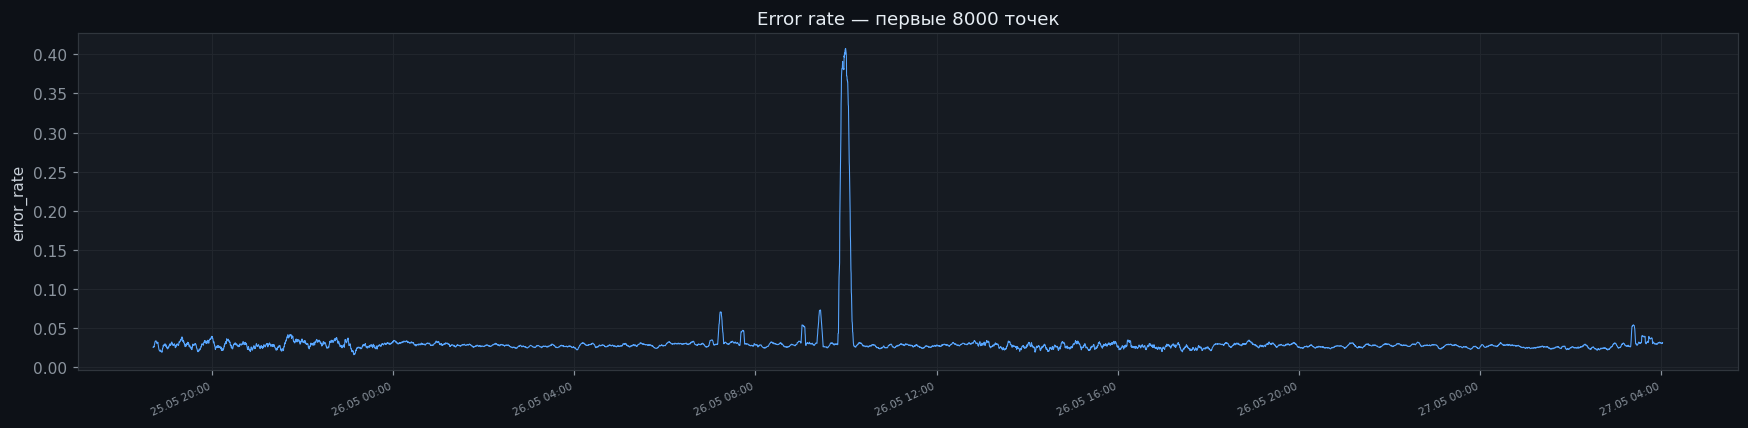

In [2]:
DATA_PATH = '../data/error_rate_dataset.csv'

df_raw = pd.read_csv(DATA_PATH)
df_raw['datetime'] = pd.to_datetime(df_raw['timestamp'], unit='s')
df_raw = df_raw.sort_values('datetime').reset_index(drop=True)

full_idx = pd.date_range(df_raw['datetime'].iloc[0],
                         df_raw['datetime'].iloc[-1], freq='15s')
df = (df_raw.drop_duplicates('timestamp')
            .set_index('datetime')[['error_rate']]
            .reindex(full_idx))
df.index.name = 'datetime'
gaps = df['error_rate'].isna().sum()
df['error_rate'] = df['error_rate'].interpolate('time').fillna(0.0)
# error_rate ∈ [0, 1]; защищаемся от выбросов
df['error_rate'] = df['error_rate'].clip(0.0, 1.0)

er = df['error_rate']
print(f"Строк: {len(df):,}  |  Пропусков заполнено: {gaps}")
print(f"Период: {df.index[0]}  →  {df.index[-1]}")
print(f"error_rate: mean={er.mean():.5f}  std={er.std():.5f}  "
      f"min={er.min():.5f}  max={er.max():.5f}")

# Базовый график
fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#161b22')
ax.plot(er.index[:8000], er.values[:8000], color=C['actual'], lw=0.7)
ax.set_title('Error rate — первые 8000 точек'); ax.set_ylabel('error_rate')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right', fontsize=7)
plt.tight_layout(); plt.show()

## 3. Признаки для Ridge
Те же лаги/окна/EWM/гармоники, что в CPU-ноутбуке — это позволяет переиспользовать `RidgeFeatureBuilder` и не править инференс.

In [3]:
def make_features(series, extra_cols: dict | None = None):
    """
    Признаки для Ridge — копия `make_features` из cpu_walkforward.ipynb.
    extra_cols (dict[str, pd.Series]) — дополнительные колонки (например, one-hot
    handler-а для RPS); индексируются тем же индексом, что и series.
    """
    f = pd.DataFrame(index=series.index)
    for lag in [1, 2, 4, 8, 16, 32, 60, 120, 240]:
        f[f'lag_{lag}'] = series.shift(lag)
    for w in [4, 20, 60, 120, 240]:
        f[f'roll_mean_{w}'] = series.shift(1).rolling(w).mean()
        f[f'roll_std_{w}']  = series.shift(1).rolling(w).std()
    for span in [4, 20, 60]:
        f[f'ewm_{span}'] = series.shift(1).ewm(span=span).mean()
    f['hour_sin']   = np.sin(2*np.pi*series.index.hour/24)
    f['hour_cos']   = np.cos(2*np.pi*series.index.hour/24)
    f['minute_sin'] = np.sin(2*np.pi*series.index.minute/60)
    f['minute_cos'] = np.cos(2*np.pi*series.index.minute/60)
    f['diff_1']  = series.diff(1).shift(1)
    f['diff_20'] = series.diff(20).shift(1)
    if extra_cols:
        for k, v in extra_cols.items():
            f[k] = v.reindex(f.index).values
    return f

BASE_FEATURE_COLS = (
    [f'lag_{l}'       for l in [1, 2, 4, 8, 16, 32, 60, 120, 240]]
    + [f'roll_mean_{w}' for w in [4, 20, 60, 120, 240]]
    + [f'roll_std_{w}'  for w in [4, 20, 60, 120, 240]]
    + [f'ewm_{s}'       for s in [4, 20, 60]]
    + ['hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'diff_1', 'diff_20']
)
LAGS         = [1, 2, 4, 8, 16, 32, 60, 120, 240]
ROLL_WINDOWS = [4, 20, 60, 120, 240]
EWM_SPANS    = [4, 20, 60]
MIN_HISTORY_POINTS = max(max(LAGS), max(ROLL_WINDOWS)) + 1   # 241
ALPHA_RIDGE  = 10.0

print(f"Признаков без extra: {len(BASE_FEATURE_COLS)}")

Признаков без extra: 28


## 4. Walk-forward (Схема 2)

In [4]:
def walk_forward_eval(series, horizon_min, n_passes=5,
                      train_frac=0.7, alpha_ridge=10.0,
                      extra_cols: dict | None = None,
                      feature_cols: list | None = None,
                      do_hw: bool = True, hw_period: int = 240):
    """
    Схема 2 (walk-forward, скользящее окно фиксированного размера).
    Возвращает усреднённые метрики Ridge / Naive / Holt-Winters.
    """
    h = int(horizon_min * 60 / FREQ_SEC)
    N = len(series)
    train_size = int(N * train_frac)

    delta = h
    max_passes = (N - train_size) // delta
    K = min(n_passes, max_passes)
    if K == 0:
        return None

    fcols = feature_cols or BASE_FEATURE_COLS
    X_all = make_features(series, extra_cols=extra_cols)[fcols]
    y_all_shift = series.shift(-h).rename('target')
    data = pd.concat([X_all, y_all_shift], axis=1).dropna()

    ridge_metrics, naive_metrics, hw_metrics = [], [], []
    all_preds = []
    y_arr = series.values

    for k in range(K):
        train_start = k * delta
        train_end   = train_start + train_size
        test_end    = train_end + delta
        if test_end > N:
            break

        tr_data = data.iloc[train_start:train_end].dropna()
        te_data = data.iloc[train_end:test_end].dropna()
        if len(tr_data) < 50 or len(te_data) == 0:
            continue

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(tr_data.drop(columns='target'))
        Xte = scaler.transform(te_data.drop(columns='target'))

        ridge = Ridge(alpha=alpha_ridge)
        ridge.fit(Xtr, tr_data['target'])
        y_pred_r = ridge.predict(Xte)
        y_true   = te_data['target'].values

        # Naive baseline — predict-last-known-window-shift
        naive_te = y_arr[train_end - h:test_end - h][:len(y_true)]

        # Holt-Winters
        if do_hw:
            try:
                hw_train = series.iloc[train_start:train_end]
                hw_m = ExponentialSmoothing(
                    hw_train, seasonal='add', seasonal_periods=hw_period, trend='add'
                ).fit(optimized=True)
                hw_fc = np.asarray(hw_m.forecast(delta))[:len(y_true)]
            except Exception:
                hw_fc = naive_te
        else:
            hw_fc = naive_te

        def mets(yt, yp):
            yt, yp = np.asarray(yt), np.asarray(yp)
            mask = np.isfinite(yt) & np.isfinite(yp)
            yt, yp = yt[mask], yp[mask]
            if len(yt) == 0:
                return dict(MAE=np.nan, RMSE=np.nan, R2=np.nan)
            return dict(
                MAE=mean_absolute_error(yt, yp),
                RMSE=np.sqrt(mean_squared_error(yt, yp)),
                R2=r2_score(yt, yp),
            )

        ridge_metrics.append(mets(y_true, y_pred_r))
        naive_metrics.append(mets(y_true, naive_te))
        hw_metrics.append(mets(y_true, hw_fc))

        te_times = series.index[train_end:test_end]
        all_preds.append(dict(
            k=k+1, times=te_times[:len(y_true)],
            y_true=y_true, ridge=y_pred_r, naive=naive_te, hw=np.asarray(hw_fc),
        ))

    def avg(mlist):
        df = pd.DataFrame(mlist)
        return df[['MAE','RMSE','R2']].mean()

    return dict(
        ridge=avg(ridge_metrics), naive=avg(naive_metrics), hw=avg(hw_metrics),
        passes=all_preds, K=len(ridge_metrics),
    )

print("Функция walk_forward_eval готова ✅  (метрика: error_rate)")

Функция walk_forward_eval готова ✅  (метрика: error_rate)


In [5]:
print("Запуск walk-forward оценки для error_rate ...")
wf_results = {}
for h_min in HORIZONS_MIN:
    print(f"  Горизонт {h_min} мин ...", end='  ')
    # HW с периодом 240 (1 ч) — у редких событий ошибки сезонность может быть слабой,
    # но оставляем для сравнимости с CPU.
    res = walk_forward_eval(er, h_min, n_passes=5, train_frac=0.70,
                            alpha_ridge=ALPHA_RIDGE)
    wf_results[h_min] = res
    if res:
        print(f"K={res['K']}  Ridge MAE={res['ridge']['MAE']:.5f}  "
              f"Naive MAE={res['naive']['MAE']:.5f}  "
              f"HW MAE={res['hw']['MAE']:.5f}")
    else:
        print("пропущен")

print("\n✅ Walk-forward завершён")

Запуск walk-forward оценки для error_rate ...
  Горизонт 1 мин ...  K=5  Ridge MAE=0.00065  Naive MAE=0.00234  HW MAE=0.00224
  Горизонт 5 мин ...  K=5  Ridge MAE=0.00182  Naive MAE=0.00147  HW MAE=0.00347
  Горизонт 10 мин ...  K=5  Ridge MAE=0.00353  Naive MAE=0.00264  HW MAE=0.00279
  Горизонт 15 мин ...  K=5  Ridge MAE=0.00258  Naive MAE=0.00336  HW MAE=0.00768
  Горизонт 30 мин ...  K=5  Ridge MAE=0.00247  Naive MAE=0.00224  HW MAE=0.00933
  Горизонт 45 мин ...  K=5  Ridge MAE=0.00293  Naive MAE=0.00235  HW MAE=0.01699
  Горизонт 60 мин ...  K=5  Ridge MAE=0.00363  Naive MAE=0.00232  HW MAE=0.01296

✅ Walk-forward завершён


## 5. Сравнение моделей на всех горизонтах

=== Сравнительная таблица метрик (Walk-forward avg, error_rate) ===


,Ridge MAE,Naive MAE,HW MAE,Ridge RMSE,Naive RMSE,Ridge R²,HW R²
"Горизонт, мин",,,,,,,
1,0.0006,0.0023,0.0022,0.0007,0.0024,-31.8056,-360.6693
5,0.0018,0.0015,0.0035,0.0021,0.0017,-7.9095,-37.2143
10,0.0035,0.0026,0.0028,0.0038,0.0030,-20.8773,-18.6739
15,0.0026,0.0034,0.0077,0.0031,0.0039,-3.6343,-46.5011
30,0.0025,0.0022,0.0093,0.0028,0.0028,-5.6922,-122.9983
45,0.0029,0.0024,0.0170,0.0034,0.0028,-5.3718,-283.9299
60,0.0036,0.0023,0.0130,0.0041,0.0029,-9.2445,-114.3049


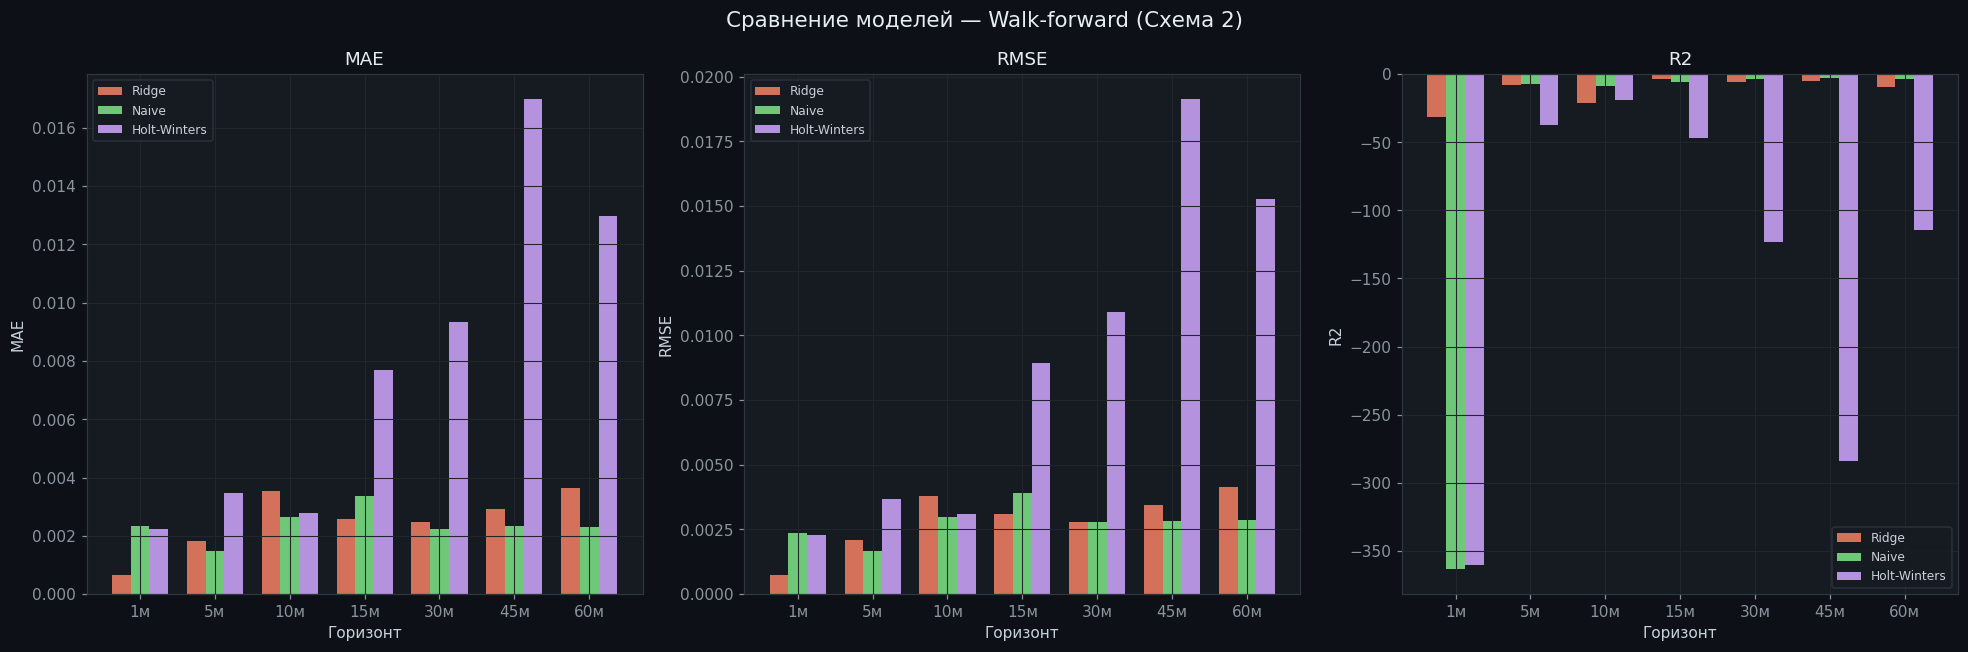

In [6]:
rows = []
for h in HORIZONS_MIN:
    res = wf_results.get(h)
    if res is None:
        continue
    rows.append({
        'Горизонт, мин': h,
        'Ridge MAE':  res['ridge']['MAE'],
        'Naive MAE':  res['naive']['MAE'],
        'HW MAE':     res['hw']['MAE'],
        'Ridge RMSE': res['ridge']['RMSE'],
        'Naive RMSE': res['naive']['RMSE'],
        'Ridge R²':   res['ridge']['R2'],
        'HW R²':      res['hw']['R2'],
    })

cmp = pd.DataFrame(rows).set_index('Горизонт, мин')
print("=== Сравнительная таблица метрик (Walk-forward avg, error_rate) ===")
display(cmp.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Сравнение моделей — Walk-forward (Схема 2)', fontsize=14, color='#e6edf3')

hlist = [h for h in HORIZONS_MIN if wf_results.get(h)]
x = np.arange(len(hlist))
w = 0.25
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.set_facecolor('#161b22')
    rv = [wf_results[h]['ridge'][metric] for h in hlist]
    nv = [wf_results[h]['naive'][metric] for h in hlist]
    hv = [wf_results[h]['hw'][metric]    for h in hlist]
    ax.bar(x - w, rv, w, color=C['ridge'], alpha=0.85, label='Ridge')
    ax.bar(x,     nv, w, color=C['naive'], alpha=0.85, label='Naive')
    ax.bar(x + w, hv, w, color=C['hw'],    alpha=0.85, label='Holt-Winters')
    ax.set_xticks(x); ax.set_xticklabels([f'{h}м' for h in hlist])
    ax.set_xlabel('Горизонт'); ax.set_ylabel(metric); ax.set_title(metric)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Финальное обучение Ridge на горизонте 5 мин и сохранение
Фиксируем горизонт 5 мин (= 20 шагов по 15 с), обучаемся на всей истории, сохраняем `models/error_rate_forecast_model.joblib` + `models/error_rate_model_config.json`.

In [7]:
FINAL_HORIZON_MIN   = 5
FINAL_HORIZON_STEPS = int(FINAL_HORIZON_MIN * 60 / FREQ_SEC)   # 20 шагов

FEATURE_COLS = list(BASE_FEATURE_COLS)

X_full = make_features(er)[FEATURE_COLS]
y_full = er.shift(-FINAL_HORIZON_STEPS).rename('target')
data_full = pd.concat([X_full, y_full], axis=1).dropna()
print(f"Размер обучающей выборки после dropna: {len(data_full):,} строк")

X_train = data_full[FEATURE_COLS].values
y_train = data_full['target'].values

final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train)
final_ridge = Ridge(alpha=ALPHA_RIDGE).fit(X_train_scaled, y_train)

y_pred_in = final_ridge.predict(X_train_scaled)
print(f"In-sample:   MAE={mean_absolute_error(y_train, y_pred_in):.5f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_train, y_pred_in)):.5f}  "
      f"R²={r2_score(y_train, y_pred_in):.4f}")

wf5 = wf_results.get(5)
if wf5:
    r = wf5['ridge']
    print(f"Walk-forward 5м: MAE={r['MAE']:.5f}  RMSE={r['RMSE']:.5f}  R²={r['R2']:.4f}")

# ── Сохранение ─────────────────────────────────────────────────────────
MODELS_DIR  = Path('../models'); MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH  = MODELS_DIR / 'error_rate_forecast_model.joblib'
CONFIG_PATH = MODELS_DIR / 'error_rate_model_config.json'

bundle = {
    'model': final_ridge,
    'scaler': final_scaler,
    'feature_cols': FEATURE_COLS,
    'meta': {
        'model_type': 'ridge',
        'metric_type': 'error_rate',
        'forecast_horizon_steps': FINAL_HORIZON_STEPS,
        'forecast_horizon_seconds': FINAL_HORIZON_STEPS * FREQ_SEC,
        'scrape_interval_sec': FREQ_SEC,
        'lags': LAGS,
        'rolling_windows': ROLL_WINDOWS,
        'ewm_spans': EWM_SPANS,
        'min_history_points': MIN_HISTORY_POINTS,
        'alpha': ALPHA_RIDGE,
    },
}
joblib.dump(bundle, MODEL_PATH)
print(f"✅ Модель сохранена: {MODEL_PATH.resolve()}")

config_json = {
    'model_type': 'ridge',
    'metric_type': 'error_rate',
    'feature_cols': FEATURE_COLS,
    'categorical_features': [],
    'forecast_horizon_steps': FINAL_HORIZON_STEPS,
    'forecast_horizon_seconds': FINAL_HORIZON_STEPS * FREQ_SEC,
    'scrape_interval_sec': FREQ_SEC,
    'lags': LAGS,
    'rolling_windows': ROLL_WINDOWS,
    'ewm_spans': EWM_SPANS,
    'min_history_points': MIN_HISTORY_POINTS,
    'alpha': ALPHA_RIDGE,
    'walk_forward_5min': (
        {k: float(v) for k, v in wf_results[5]['ridge'].items()}
        if wf_results.get(5) else None
    ),
}
with open(CONFIG_PATH, 'w') as f:
    json.dump(config_json, f, indent=2, ensure_ascii=False)
print(f"✅ Конфиг сохранён:  {CONFIG_PATH.resolve()}")

loaded = joblib.load(MODEL_PATH)
last_row = data_full[FEATURE_COLS].iloc[[-1]].values
last_scaled = loaded['scaler'].transform(last_row)
print(f"\nКонтрольная загрузка: предсказание для последней точки = "
      f"{float(loaded['model'].predict(last_scaled)[0]):.5f}")

Размер обучающей выборки после dropna: 29,874 строк
In-sample:   MAE=0.00500  RMSE=0.01602  R²=0.5293
Walk-forward 5м: MAE=0.00182  RMSE=0.00209  R²=-7.9095
✅ Модель сохранена: /Users/anastasiagusak/Documents/4 курс/MLPredictor/models/error_rate_forecast_model.joblib
✅ Конфиг сохранён:  /Users/anastasiagusak/Documents/4 курс/MLPredictor/models/error_rate_model_config.json

Контрольная загрузка: предсказание для последней точки = 0.02573
